In [1]:
import navis
import plotly
import nbformat
print(f"Wersja navis: {navis.__version__}")
# Różne typy neuronów: 
n_tree = navis.example_neurons(n=1, kind='skeleton')
n_tree

n_mesh = navis.example_neurons(n=1, kind='mesh')
n_mesh

Wersja navis: 1.11.0


,
type,navis.MeshNeuron
name,DA1_lPN_R
id,1734350788
units,8 nanometer
n_vertices,6309
n_faces,13054


# Typy reprezentacji neuronu 

- TreeNeuron 
- MeshNeuron 
- VoxelNeuron 
- Dotprops 

NeuronList - jest kontenerem na neurony 

| Klasa         | Reprezentacja            | Najważniejsze dane         | Typowe zastosowanie                |
| ------------- | ------------------------ | -------------------------- | ---------------------------------- |
| `TreeNeuron`  | szkielet/graf            | `nodes`, `graph`           | topologia, rozgałęzienia, długości |
| `MeshNeuron`  | powierzchnia 3D          | `vertices`, `faces`        | EM, geometria, objętość            |
| `VoxelNeuron` | woksele 3D               | `voxels`, `grid`, `values` | obrazy mikroskopowe                |
| `Dotprops`    | chmura punktów + wektory | `points`, `vect`           | NBLAST, podobieństwo morfologiczne |
| `NeuronList`  | kolekcja                 | wiele neuronów             | analiza populacji                  |


TreeNeuron reprezentuje neuron jako strukturę drzewiastą ('drzewiasty szkielet') - struktura typu DAG. Ten format jest używany do opisu topologii neuronów i często używany w plikach .swc. 

MeshNeurons - składa się z wierzchołków i ścian, stanowi wynik segmentacji obrazu. Właściwości .vertices i .faces.
navis.MeshNeuron przechowuje wierzchołki i ściany jako tablice numpy. Dane są bardzo charakterystyczne dla segmentacji EM, gdzie otrzymujesz objętość komórki, a nie tylko jej cienki szkielet.

VoxelNeuron - ten typ reprezentuje neurony jako obrazy 3D lub współrzędne wokseli (x,y,z). NAVis może przechowywać VoxelNeuron jako gęstą siatkę 3D (neuron.grid) albo jako listę współrzędnych aktywnych wokseli (neuron.voxels) oraz wartości (neuron.values)

Dotprops - typ reprezentuje neurony w postaci chmur punktów, w których każdy punkt jest powiązany z wektorem opisującym lokalną orientacją (powstaje np. z danych o natężeniu światła lub na bazie szkieletów). Dane znajdują się w neuron.points i neuron.vect Używana do porównywania neuronów w NBLAST. 


            skeletonize()
MeshNeuron ─────────────────────→ TreeNeuron

TreeNeuron ─── make_dotprops() ─→ Dotprops

TreeNeuron ───── voxelize() ────→ VoxelNeuron

TreeNeuron ─────── mesh() ──────→ MeshNeuron



In [9]:
a = navis.example_neurons(n=1, kind='mesh') 
#wokselizacja: 
vx = navis.voxelize(a, pitch='0.5 microns', smooth=2, counts=True) 
vx 

,
type,navis.VoxelNeuron
name,DA1_lPN_R
id,1734350788
units,500.0 nanometer
shape,"(298, 392, 286)"
dtype,float32


## Connectors: 

Odnosi się do cyfrowych punktów reprezentujących synapsy i inne połączenia między neuronami

Tabela .connectors grupuje wszystkie punkty kontaktu. NAVis wykorzystuje connectors do reprezentowania m.in. synaps pre- i postsynaptycznych, ale system pozwala też reprezentować i inne rodzaje konektorów. 

Tabelka połączeń zawiera współrzędne x, y, z i typ każdego połączenia: 

Connectors może być również użyte do tworzenia wykresów. 

presynapsy - czerwone punkty, a niebieskie to postsynapsy. 

In [5]:
neuron_connectors = navis.example_neurons(n=1) 
neuron_connectors.connectors.head() 

,connector_id,node_id,type,x,y,z,roi,confidence
0,0,1436,pre,6444,21608,14516,LH(R),0.959
1,1,1436,pre,6457,21634,14474,LH(R),0.997
2,2,2638,pre,4728,23538,14179,LH(R),0.886
3,3,1441,pre,5296,22059,16048,LH(R),0.967
4,4,1872,pre,4838,23114,15146,LH(R),0.990


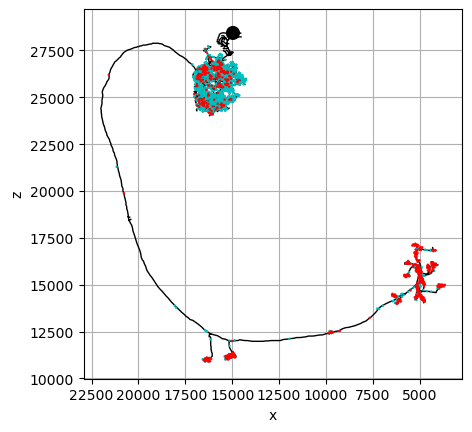

In [7]:
fig, ax = navis.plot2d(neuron_connectors, connectors=True, color='k', cn_size=3, view=('-x', 'z'), method='2d') 

# Soma neuronu 

Dotyczy neuronów, które nie zostały ucięte. Ważne przy obliczaniu odległości i wizualizacji. 

Ciało komórki nerwowej zapisane jako szczególny punkt/pozycja w cyfrowej reprezentacji neuronu. (węzeł rozpoznany jak ciało komórki)

In [17]:
b = navis.example_neurons(1, kind='skeleton')
print(f'ID w tabeli: {b.soma}') 
print(f'Pozycja somy (współrzędne): {b.soma_pos}')

ID w tabeli: 4177
Pozycja somy (współrzędne): [[14957.1 36540.7 28432.4]]


## Units
Mówi w jakiej jednostce i skali zapisane są współrzędne przestrzenne neuronu. 

Zamiana jednostek następuje poprzez convert_units() 

In [22]:
print(f"Jednostki dla neuronu b = {b.units:.1f}")
b_um = b.convert_units('micrometers')
print(f'Jednostki po konwersji: {b_um.units}')

Jednostki dla neuronu b = 8.0 nanometer
Jednostki po konwersji: 1.0 micrometer


In [6]:
sk = navis.example_neurons(1, kind='skeleton') 
navis.reroot_skeleton(sk, sk.soma, inplace=True) 
lh = navis.example_volume('LH') 
navis.in_volume(sk, lh, inplace=True)
navis.plot3d(sk, color='red')

### Parametr inplace 

Inplace = True - operacje są wykonywane bezpośrednio na wejściowym neuronie/neuronach 

Inplace = False - służy do porównywania stanów przed i po 

root - korzeń drzewa (szczególny węzeł) 

reroot zmienia węzeł uznawany za korzeń drzewa, zmienia orientację względem korzenia. Pozwala to badać hierarchię rozgałęzień. 


In [9]:
original = navis.example_neurons(n=1, kind='skeleton') 
rerooted = navis.reroot_skeleton(original, original.soma, inplace=False) 
""" 
Ustawiam węzeł somy jako punkt odniesienia drzewa
"""
print(original.root) 
print("Root:", rerooted.root) 
print("Soma:", rerooted.soma)

[1]
Root: [4177]
Soma: 4177


In [13]:
""".graph - zamiana na graf networkx i praca z algorytmami grafowymi""" 
neuron = navis.example_neurons(1, kind='skeleton') 
G = neuron.graph 

print('V=', G.number_of_nodes()) 
print('E=', G.number_of_edges()) 

high_deg = [node for node, degree in G.degree() if degree>=5] 
print(high_deg)

V= 4465
E= 4464
[687, 802]


In [ ]:
m = navis.example_neurons(1, kind='mesh') 

s= navis.skeletonize(m) 

dp = navis.make_dotprops(s, k=5) 

vx = navis.voxelize(m, pitch='2 microns', smooth=1, counts=True)  

mm = navis.mesh(vx.threshold(0.5)) 

In [15]:
navis.plot3d([m,s], color=[(0.7, 0.7, 0.7, 0.2), 'r'], radius=False)

In [16]:
navis.plot3d([m, dp], color=[(0.7, 0.7, 0.7, 0.2),'r'])

In [17]:
navis.plot3d([m*8, vx])

In [18]:
navis.plot3d([vx, mm], fig_autosize=True)